# Моделирование: препроцессинг и проверка

**Train:** 672 пациента (80%)
**Test:** 168 пациентов (20%)
**Признаков:** 78
**Метрика:** Macro-F1 по `anemia_class`
**Stratified:** по `anemia_class`

In [1]:
# ============ ИМПОРТЫ ============
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocess import (
    load_features, get_feature_columns, split_data,
    LEAKAGE_COLS, TARGET_MULTI, RANDOM_STATE
)

# Настройки
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

print("Импорты загружены")

Импорты загружены


In [2]:
# ============ ЗАГРУЗКА И SPLIT ============
df = load_features('../data/processed/df_features.csv')
print(f"Загружено: {df.shape}")

features = get_feature_columns(df)
print(f"Признаков: {len(features)}")

X_train, X_test, y_train, y_test, ids_train, ids_test = split_data(df)
print(f"\nTrain: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Загружено: (840, 89)
Признаков: 76

Train: (672, 76)
Test:  (168, 76)


In [3]:
# ============ ПРОВЕРКА СТРАТИФИКАЦИИ ============
train_dist = y_train.value_counts(normalize=True).round(3)
test_dist = y_test.value_counts(normalize=True).round(3)

comparison = pd.DataFrame({
    'train': train_dist,
    'test': test_dist,
    'diff': (train_dist - test_dist).abs()
})

print(comparison)
print(f"\nMax diff: {comparison['diff'].max():.4f}")

                             train   test  diff
anemia_class                                   
B12_deficiency_anemia        0.077  0.077   0.0
B12_deficiency_no_anemia     0.060  0.060   0.0
B6_deficiency                0.042  0.042   0.0
anemia_other                 0.089  0.089   0.0
copper_deficiency            0.042  0.042   0.0
folate_deficiency_anemia     0.060  0.060   0.0
folate_deficiency_no_anemia  0.048  0.048   0.0
inflammation_anemia          0.077  0.077   0.0
iron_deficiency_anemia       0.137  0.137   0.0
latent_deficiency            0.101  0.101   0.0
mixed_deficiency             0.137  0.137   0.0
no_anemia_no_deficiency      0.131  0.131   0.0

Max diff: 0.0000


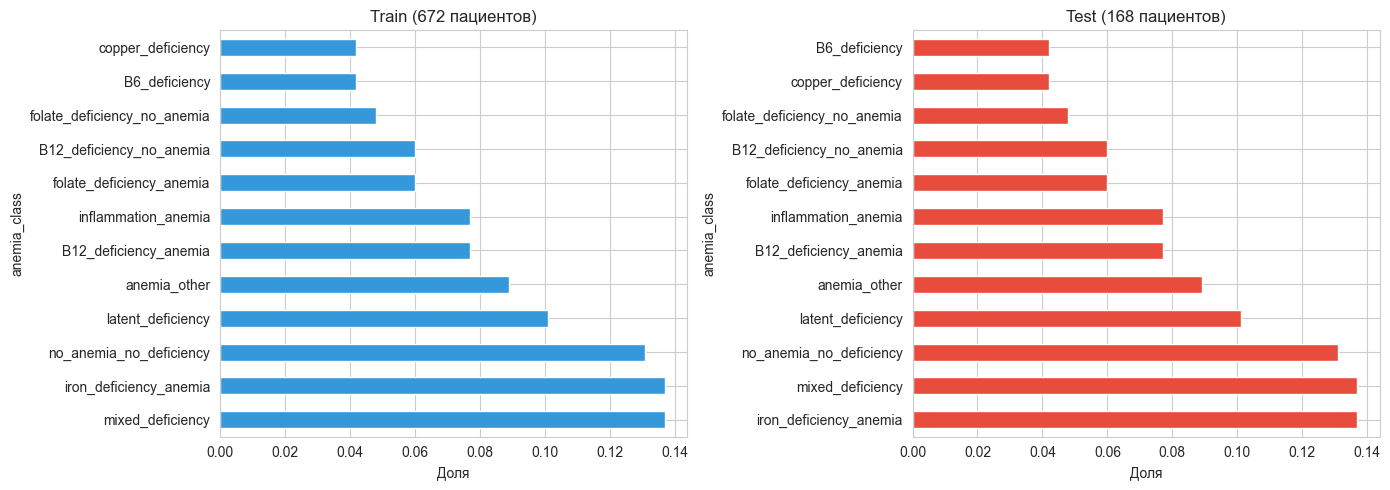

In [4]:
# ============ ВИЗУАЛИЗАЦИЯ ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_dist.plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title(f'Train ({len(y_train)} пациентов)')
axes[0].set_xlabel('Доля')

test_dist.plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title(f'Test ({len(y_test)} пациентов)')
axes[1].set_xlabel('Доля')

plt.tight_layout()
plt.show()

## Итоги препроцессинга

- **Train:** 672 пациента (80%)
- **Test:** 168 пациентов (20%)
- **Признаков:** **76** (без утечек)
- **Stratified:** по `anemia_class`
- **Max diff пропорций:** 0.0000 — идеальная стратификация
- **Утечки исключены (13):**
  - Таргеты (10): `anemia`, `iron_deficiency`, `B12_deficiency`, `folate_deficiency`, `B6_deficiency`, `copper_deficiency`, `inflammation_anemia`, `mixed_deficiency`, `anemia_class`, `deficiency_cause`.
  - ID (1): `patient_id`.
  - Строковые (2): `sex` (дубликат `sex_M`), `age_group` (дубликат `age_years`).

### Следующий этап
- Обучение моделей 
- SHAP-интерпретация 

## Обучение моделей

**Train:** 672 × 76
**Test:** 168 × 76
**Классов:** 12
**Метрика:** Macro-F1

### План
1. Baseline (Dummy, LogisticRegression)
2. RandomForest
3. CatBoost
4. XGBoost / LightGBM
5. Сравнение и финальная модель

In [5]:
# ============ ИМПОРТЫ ДЛЯ МОДЕЛЕЙ ============
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
print("Импорты для моделей загружены")

Импорты для моделей загружены


In [6]:
# ============ BASELINE 1: DummyClassifier ============
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("=== DummyClassifier (most_frequent) ===")
print(f"Accuracy:     {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Macro-F1:     {f1_score(y_test, y_pred_dummy, average='macro'):.4f}")
print(f"Balanced acc: {balanced_accuracy_score(y_test, y_pred_dummy):.4f}")

=== DummyClassifier (most_frequent) ===
Accuracy:     0.1369
Macro-F1:     0.0201
Balanced acc: 0.0833


In [7]:
# ============ BASELINE 2: LogisticRegression ============
# LogisticRegression не работает с NaN — проверяем
print(f"NaN в X_train: {X_train.isna().sum().sum()}")
print(f"NaN в X_test:  {X_test.isna().sum().sum()}")

NaN в X_train: 9432
NaN в X_test:  2335


In [11]:
# ============ ИМПУТАЦИЯ ДЛЯ ЛИНЕЙНЫХ МОДЕЛЕЙ ============
from sklearn.impute import SimpleImputer

# Медиана по train (не по test — избегаем утечки)
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"X_train_imp: {X_train_imp.shape}, NaN: {X_train_imp.isna().sum().sum()}")
print(f"X_test_imp:  {X_test_imp.shape}, NaN: {X_test_imp.isna().sum().sum()}")

X_train_imp: (672, 76), NaN: 0
X_test_imp:  (168, 76), NaN: 0


In [12]:
# ============ LOGISTIC REGRESSION ============
logreg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

logreg.fit(X_train_imp, y_train)
y_pred_logreg = logreg.predict(X_test_imp)

print("=== LogisticRegression ===")
print(f"Accuracy:     {accuracy_score(y_test, y_pred_logreg):.4f}")
print(f"Macro-F1:     {f1_score(y_test, y_pred_logreg, average='macro'):.4f}")
print(f"Balanced acc: {balanced_accuracy_score(y_test, y_pred_logreg):.4f}")

=== LogisticRegression ===
Accuracy:     0.8631
Macro-F1:     0.8638
Balanced acc: 0.8756


## RandomForest

Деревья решений — работают с NaN **нативно**. Не нужна импутация.

In [13]:
# ============ RANDOM FOREST ============
from sklearn.ensemble import RandomForestClassifier

# RF работает с NaN нативно — импутация не нужна
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== RandomForest ===")
print(f"Accuracy:     {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Macro-F1:     {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"Balanced acc: {balanced_accuracy_score(y_test, y_pred_rf):.4f}")

=== RandomForest ===
Accuracy:     0.9107
Macro-F1:     0.9053
Balanced acc: 0.9043


## CatBoost

Градиентный бустинг от Яндекса. Работает с NaN **нативно**.

In [14]:
# ============ CATBOOST ============
from catboost import CatBoostClassifier

# CatBoost работает с NaN нативно
catboost = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='MultiClass',
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=100,
    allow_writing_files=False
)

catboost.fit(X_train, y_train)
y_pred_catboost = catboost.predict(X_test).flatten()

print("\n=== CatBoost ===")
print(f"Accuracy:     {accuracy_score(y_test, y_pred_catboost):.4f}")
print(f"Macro-F1:     {f1_score(y_test, y_pred_catboost, average='macro'):.4f}")
print(f"Balanced acc: {balanced_accuracy_score(y_test, y_pred_catboost):.4f}")

0:	learn: 2.4208232	total: 188ms	remaining: 1m 33s
100:	learn: 0.5935150	total: 2.99s	remaining: 11.8s
200:	learn: 0.2845760	total: 5.57s	remaining: 8.28s
300:	learn: 0.1852221	total: 8.18s	remaining: 5.4s
400:	learn: 0.1373174	total: 10.7s	remaining: 2.65s
499:	learn: 0.1092524	total: 13.4s	remaining: 0us

=== CatBoost ===
Accuracy:     0.8869
Macro-F1:     0.8693
Balanced acc: 0.8712


## LabelEncoder для XGBoost и LightGBM

XGBoost и LightGBM требуют **числовые** метки (0–11). Преобразуем `y_train` и `y_test` через `LabelEncoder`.

In [16]:
# ============ LABEL ENCODER ДЛЯ XGBOOST/LIGHTGBM ============
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train)

y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

print(f"Классы: {list(le.classes_)}")
print(f"\ny_train_enc (первые 10): {y_train_enc[:10]}")
print(f"y_test_enc  (первые 10): {y_test_enc[:10]}")

Классы: ['B12_deficiency_anemia', 'B12_deficiency_no_anemia', 'B6_deficiency', 'anemia_other', 'copper_deficiency', 'folate_deficiency_anemia', 'folate_deficiency_no_anemia', 'inflammation_anemia', 'iron_deficiency_anemia', 'latent_deficiency', 'mixed_deficiency', 'no_anemia_no_deficiency']

y_train_enc (первые 10): [10  5  8 10  3 11  5  6 11  7]
y_test_enc  (первые 10): [ 9  8  5  4  3  0 10  9  1 10]


## XGBoost

Градиентный бустинг. Работает с NaN **нативно**.

In [17]:
# ============ XGBOOST (числовые метки) ============
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softprob',
    num_class=12,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train, y_train_enc)  # ← числовые метки!
y_pred_xgb_enc = xgb_model.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)  # обратно в строки

print("=== XGBoost ===")
print(f"Accuracy:     {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Macro-F1:     {f1_score(y_test, y_pred_xgb, average='macro'):.4f}")
print(f"Balanced acc: {balanced_accuracy_score(y_test, y_pred_xgb):.4f}")

=== XGBoost ===
Accuracy:     0.9107
Macro-F1:     0.9046
Balanced acc: 0.9086


## LightGBM

Градиентный бустинг от Microsoft. Работает с NaN **нативно**. Требует числовые метки — используем `y_train_enc`.

In [18]:
# ============ LIGHTGBM (числовые метки) ============
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train, y_train_enc)
y_pred_lgb_enc = lgb_model.predict(X_test)
y_pred_lgb = le.inverse_transform(y_pred_lgb_enc)

print("=== LightGBM ===")
print(f"Accuracy:     {accuracy_score(y_test, y_pred_lgb):.4f}")
print(f"Macro-F1:     {f1_score(y_test, y_pred_lgb, average='macro'):.4f}")
print(f"Balanced acc: {balanced_accuracy_score(y_test, y_pred_lgb):.4f}")

=== LightGBM ===
Accuracy:     0.9048
Macro-F1:     0.8996
Balanced acc: 0.9103


## Сравнение всех моделей

Итоговая таблица по метрикам на test (168 пациентов).

In [19]:
# ============ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ============
results = pd.DataFrame({
    'Model': ['Dummy', 'LogisticRegression', 'RandomForest', 'CatBoost', 'XGBoost', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_catboost),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgb)
    ],
    'Macro-F1': [
        f1_score(y_test, y_pred_dummy, average='macro'),
        f1_score(y_test, y_pred_logreg, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_catboost, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro'),
        f1_score(y_test, y_pred_lgb, average='macro')
    ],
    'Balanced acc': [
        balanced_accuracy_score(y_test, y_pred_dummy),
        balanced_accuracy_score(y_test, y_pred_logreg),
        balanced_accuracy_score(y_test, y_pred_rf),
        balanced_accuracy_score(y_test, y_pred_catboost),
        balanced_accuracy_score(y_test, y_pred_xgb),
        balanced_accuracy_score(y_test, y_pred_lgb)
    ]
})

results = results.sort_values('Macro-F1', ascending=False).reset_index(drop=True)
print("=== Итоговая таблица ===")
print(results.round(4).to_string(index=False))

=== Итоговая таблица ===
             Model  Accuracy  Macro-F1  Balanced acc
      RandomForest    0.9107    0.9053        0.9043
           XGBoost    0.9107    0.9046        0.9086
          LightGBM    0.9048    0.8996        0.9103
          CatBoost    0.8869    0.8693        0.8712
LogisticRegression    0.8631    0.8638        0.8756
             Dummy    0.1369    0.0201        0.0833


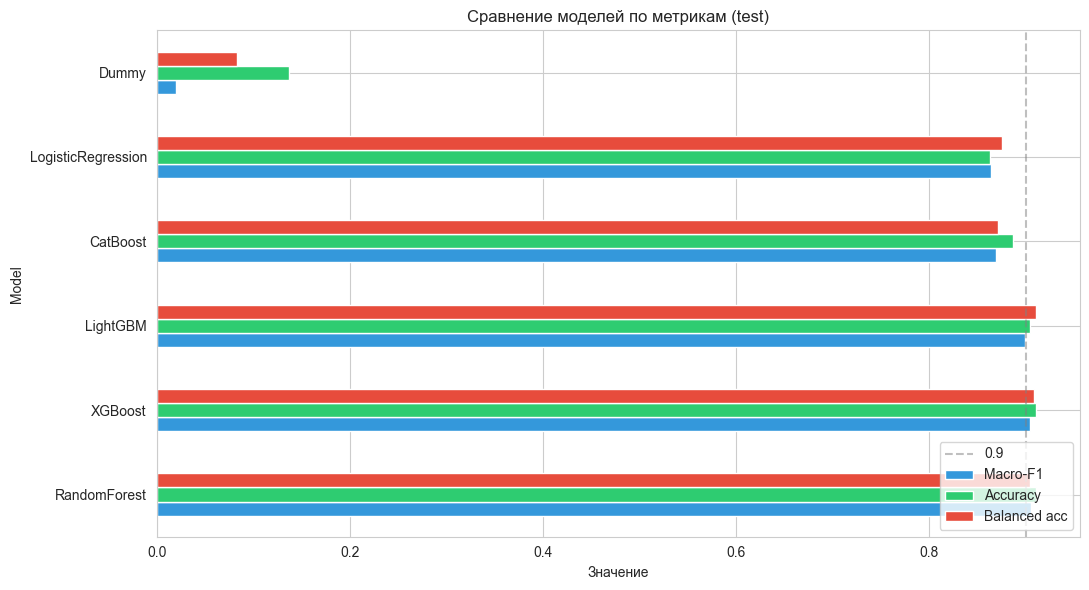

In [20]:
# ============ ВИЗУАЛИЗАЦИЯ ============
fig, ax = plt.subplots(figsize=(11, 6))
results_viz = results.set_index('Model')[['Macro-F1', 'Accuracy', 'Balanced acc']]
results_viz.plot(kind='barh', ax=ax, color=['#3498db', '#2ecc71', '#e74c3c'])
ax.set_title('Сравнение моделей по метрикам (test)')
ax.set_xlabel('Значение')
ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.5, label='0.9')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Детальные метрики по классам (лучшая модель)

In [21]:
# ============ CLASSIFICATION REPORT ============
# Определяем лучшую модель
best_idx = results['Macro-F1'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
print(f"Лучшая модель: {best_model_name} (Macro-F1 = {results.loc[best_idx, 'Macro-F1']:.4f})\n")

# Выбираем predictions лучшей модели
preds = {
    'Dummy': y_pred_dummy,
    'LogisticRegression': y_pred_logreg,
    'RandomForest': y_pred_rf,
    'CatBoost': y_pred_catboost,
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgb
}
y_pred_best = preds[best_model_name]

# Classification report
print(classification_report(y_test, y_pred_best))

Лучшая модель: RandomForest (Macro-F1 = 0.9053)

                             precision    recall  f1-score   support

      B12_deficiency_anemia       0.93      1.00      0.96        13
   B12_deficiency_no_anemia       1.00      0.90      0.95        10
              B6_deficiency       1.00      1.00      1.00         7
               anemia_other       1.00      0.87      0.93        15
          copper_deficiency       0.67      0.86      0.75         7
   folate_deficiency_anemia       1.00      0.80      0.89        10
folate_deficiency_no_anemia       0.86      0.75      0.80         8
        inflammation_anemia       0.87      1.00      0.93        13
     iron_deficiency_anemia       0.91      0.91      0.91        23
          latent_deficiency       0.94      0.94      0.94        17
           mixed_deficiency       0.95      0.87      0.91        23
    no_anemia_no_deficiency       0.84      0.95      0.89        22

                   accuracy                         

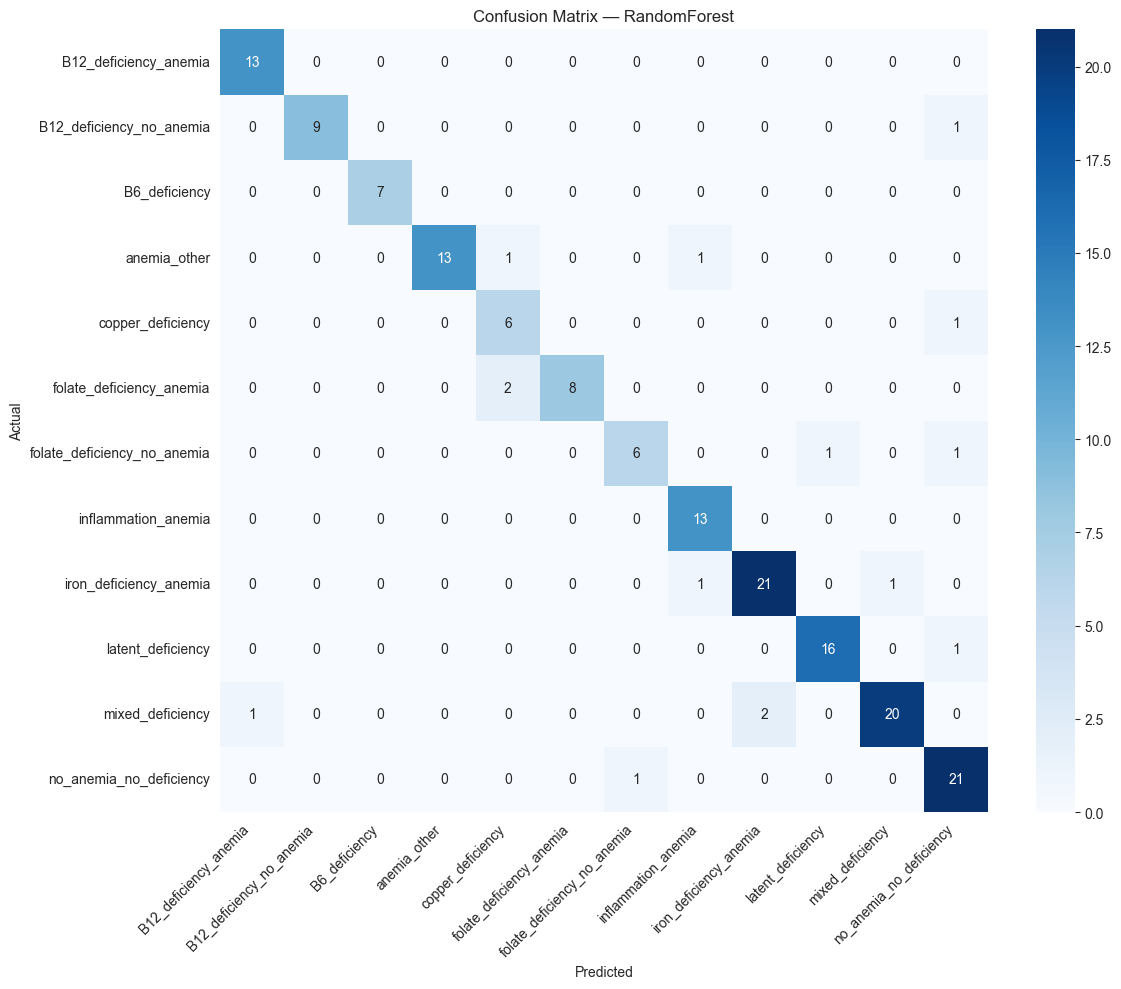

In [22]:
# ============ CONFUSION MATRIX ============
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred_best, labels=le.classes_)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Confusion Matrix — {best_model_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()